# Filter & Epoch — EEG Motor Movement / Imagery

**Goal:** Bandpass-filter the raw signal and cut it into fixed-length trials locked to the task cues.

**Dataset:** [PhysioNet EEGMMIDB](https://physionet.org/content/eegmmidb/1.0.0/) — runs 4, 8, 12 for subject 1 (left vs right hand motor imagery).

### Imports

In [12]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
from mne.datasets import eegbci

mne.set_log_level("WARNING")

# Root of the local data copy already present in the repo
DATA_DIR = Path("physionet_data/files/eegmmidb/1.0.0")

print("MNE version:", mne.__version__)
print("Data dir   :", DATA_DIR.resolve())

MNE version: 1.11.0
Data dir   : /Users/mehdidesmartin/Documents/Code/42/postCC/total-perspective-vortex/physionet_data/files/eegmmidb/1.0.0


### Load data

**Runs 4, 8, 12** are the left vs right hand **imagery** runs for subject 1. The three files are read from the local `physionet_data/` directory and concatenated into one Raw object.

In [13]:
SUBJECT = 1
# Runs 4, 8, 12 → left hand (T1) vs right hand (T2) motor imagery
IMAGERY_RUNS = [4, 8, 12]

# Build paths directly from the local data directory — no download
subject_dir = DATA_DIR / f"S{SUBJECT:03d}"
fnames = [subject_dir / f"S{SUBJECT:03d}R{run:02d}.edf" for run in IMAGERY_RUNS]

raws = [mne.io.read_raw_edf(str(f), preload=True) for f in fnames]
raw = mne.concatenate_raws(raws)

print(f"Loaded {len(fnames)} run(s) for subject {SUBJECT}")
print(f"  Sampling rate : {raw.info['sfreq']} Hz")
print(f"  Duration      : {raw.times[-1]:.1f} s")
print(f"  Channels      : {len(raw.ch_names)}")

Loaded 3 run(s) for subject 1
  Sampling rate : 160.0 Hz
  Duration      : 375.0 s
  Channels      : 64


### Check annotation durations

**The goal** is to confirm the cue length directly from the EDF file before committing to a time window.

In [14]:
print("First 12 annotations (onset, duration, description):")
for ann in raw.annotations[:12]:
    print(f"  {ann['description']:3s}  onset={ann['onset']:6.2f}s  duration={ann['duration']:.1f}s")

unique_desc = set(raw.annotations.description)
for desc in sorted(unique_desc):
    mask = raw.annotations.description == desc
    durations = raw.annotations.duration[mask]
    print(f"\n{desc}: {mask.sum()} occurrences, duration = {durations[0]:.1f}s (all identical: {len(set(durations))==1})")

First 12 annotations (onset, duration, description):
  T0   onset=  0.00s  duration=4.2s
  T2   onset=  4.20s  duration=4.1s
  T0   onset=  8.30s  duration=4.2s
  T1   onset= 12.50s  duration=4.1s
  T0   onset= 16.60s  duration=4.2s
  T1   onset= 20.80s  duration=4.1s
  T0   onset= 24.90s  duration=4.2s
  T2   onset= 29.10s  duration=4.1s
  T0   onset= 33.20s  duration=4.2s
  T2   onset= 37.40s  duration=4.1s
  T0   onset= 41.50s  duration=4.2s
  T1   onset= 45.70s  duration=4.1s

BAD boundary: 2 occurrences, duration = 0.0s (all identical: True)

EDGE boundary: 2 occurrences, duration = 0.0s (all identical: True)

T0: 45 occurrences, duration = 4.2s (all identical: True)

T1: 23 occurrences, duration = 4.1s (all identical: True)

T2: 22 occurrences, duration = 4.1s (all identical: True)


### Standardize channel names

The EDF uses non-standard names like `Fc5.` — `eegbci.standardize()` renames them to 10-20 convention before attaching the montage.

In [15]:
eegbci.standardize(raw)
raw.set_montage("standard_1020", match_case=False, on_missing="ignore")

print("First 10 channel names after standardization:", raw.ch_names[:10])

First 10 channel names after standardization: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']


## 1. Bandpass filter — 8–30 Hz

**The goal** is to keep mu (8–12 Hz) and beta (13–30 Hz), which are the rhythms that modulate during motor imagery, and discard everything outside that range.

**What we're looking for:** Clean attenuation below 8 Hz and above 30 Hz with the passband intact. A FIR filter gives a much sharper transition than IIR (Butterworth).

In [16]:
L_FREQ = 8.0   # Hz — low cut
H_FREQ = 30.0  # Hz — high cut (beta upper edge)

raw_unfiltered = raw.copy()

# FIR with narrow transition bands → much sharper stopband than IIR
raw.filter(
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    method="fir",
    l_trans_bandwidth=2.0,   # transition 6–8 Hz
    h_trans_bandwidth=2.0,   # transition 30–32 Hz
    fir_window="hamming",
)

print(f"FIR bandpass applied: {L_FREQ}–{H_FREQ} Hz")

FIR bandpass applied: 8.0–30.0 Hz


### PSD before vs after

**What we're looking for:** the blue curve should drop sharply outside 8–30 Hz with the mu and beta peaks intact.

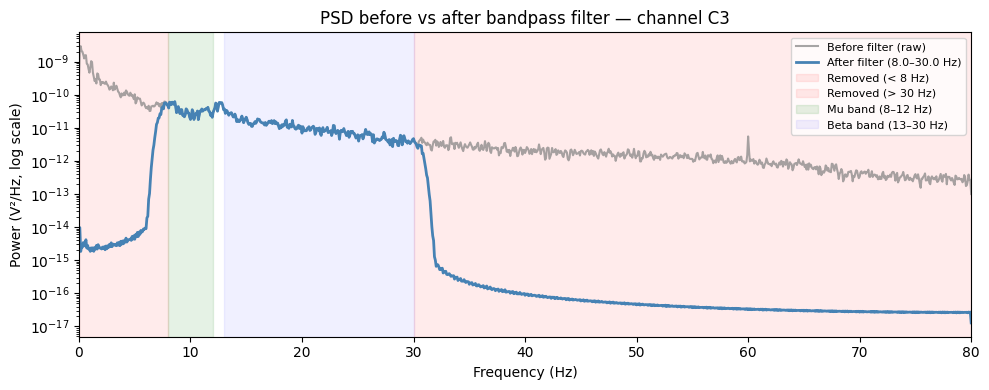

In [17]:
INSPECT_CH = "C3"   # classic left motor cortex electrode

psd_before = raw_unfiltered.compute_psd(fmax=80, picks=INSPECT_CH)
psd_after  = raw.compute_psd(fmax=80, picks=INSPECT_CH)

freqs_b, power_b = psd_before.freqs, psd_before.get_data()[0]
freqs_a, power_a = psd_after.freqs,  psd_after.get_data()[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(freqs_b, power_b, color="gray",      alpha=0.7, label="Before filter (raw)")
ax.semilogy(freqs_a, power_a, color="steelblue", linewidth=2, label=f"After filter ({L_FREQ}–{H_FREQ} Hz)")

ax.axvspan(0,      L_FREQ, color="red",  alpha=0.08, label="Removed (< 8 Hz)")
ax.axvspan(H_FREQ, 80,     color="red",  alpha=0.08, label="Removed (> 30 Hz)")
ax.axvspan(8,  12,         color="green",alpha=0.10, label="Mu band (8–12 Hz)")
ax.axvspan(13, 30,         color="blue", alpha=0.06, label="Beta band (13–30 Hz)")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (V²/Hz, log scale)")
ax.set_title(f"PSD before vs after bandpass filter — channel {INSPECT_CH}")
ax.legend(fontsize=8)
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()

## 2. Extract events

The annotations label each cue as `T0` (rest), `T1` (left hand), or `T2` (right hand). `mne.events_from_annotations()` converts them into an integer array `[sample, 0, event_id]`.

In [18]:
events, event_id = mne.events_from_annotations(raw)

print("Event ID mapping:", event_id)
print(f"Total events found: {len(events)}")

# Count per class
for label, code in event_id.items():
    n = (events[:, 2] == code).sum()
    print(f"  {label} (id={code}): {n} trials")

Event ID mapping: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total events found: 90
  T0 (id=1): 45 trials
  T1 (id=2): 23 trials
  T2 (id=3): 22 trials


## 3. Epoch [0, 4 s]

Cut the filtered signal into trials time-locked to T1 and T2 cues. The 4 s window matches the annotation duration confirmed above. Baseline correction is skipped — CSP operates on covariance, not mean amplitude.

In [19]:
TMIN = 0.0   # seconds relative to cue onset
TMAX = 4.0   # seconds relative to cue onset

# Only keep T1 (left) and T2 (right) — drop rest (T0)
task_event_id = {k: v for k, v in event_id.items() if k in ("T1", "T2")}
print("Epoching on:", task_event_id)

epochs = mne.Epochs(
    raw,
    events,
    event_id=task_event_id,
    tmin=TMIN,
    tmax=TMAX,
    picks="eeg",
    baseline=None,
    preload=True,
)

print(epochs)

Epoching on: {np.str_('T1'): 2, np.str_('T2'): 3}
<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~14.2 MiB, data loaded,
 np.str_('T1'): 23
 np.str_('T2'): 22>


## 4. Inspect

**The goal** is to confirm array shape and class balance before moving to the CSP step.

In [20]:
X = epochs.get_data()          # shape: (n_epochs, n_channels, n_times)
y = epochs.events[:, 2]        # integer labels: T1 → left, T2 → right

print(f"X shape  : {X.shape}   → (n_epochs, n_channels, n_times)")
print(f"y shape  : {y.shape}")
print()

label_names = {v: k for k, v in task_event_id.items()}
unique, counts = np.unique(y, return_counts=True)
print("Class balance:")
for code, count in zip(unique, counts):
    print(f"  {label_names[code]} (id={code}): {count} epochs")

X shape  : (45, 64, 641)   → (n_epochs, n_channels, n_times)
y shape  : (45,)

Class balance:
  T1 (id=2): 23 epochs
  T2 (id=3): 22 epochs


## 5. Visualise

ERP image (one trial per row at C3) and average evoked response T1 vs T2.

**What we're looking for:** no strong time-locked deflection is expected — motor imagery lives in oscillatory power, not the mean signal.

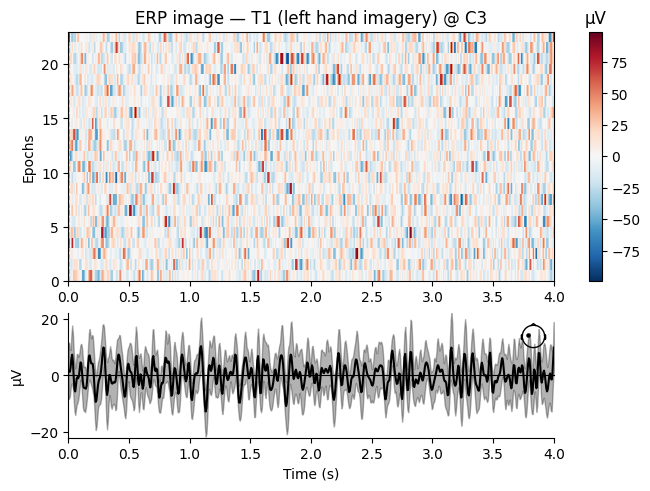

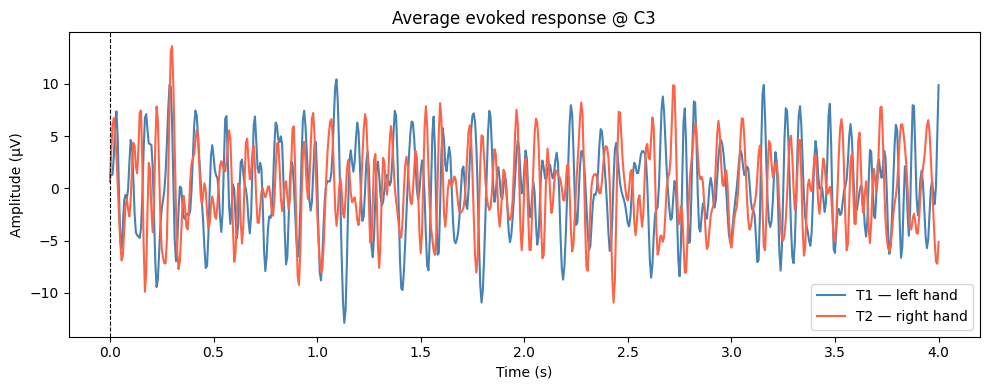

In [21]:
# --- 7a. ERP image for C3 (left motor cortex) ---
fig = epochs["T1"].plot_image(picks="C3", title="ERP image — T1 (left hand imagery) @ C3")
fig[0].set_size_inches(10, 5)
plt.show()

# --- 7b. Average evoked response: T1 vs T2 ---
evoked_t1 = epochs["T1"].average()
evoked_t2 = epochs["T2"].average()

fig, ax = plt.subplots(figsize=(10, 4))
ch_idx = epochs.ch_names.index("C3")
ax.plot(epochs.times, evoked_t1.data[ch_idx] * 1e6, label="T1 — left hand", color="steelblue")
ax.plot(epochs.times, evoked_t2.data[ch_idx] * 1e6, label="T2 — right hand", color="tomato")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Average evoked response @ C3")
ax.legend()
ax.axvline(0, color="k", linestyle="--", linewidth=0.8, label="cue onset")
plt.tight_layout()
plt.show()

## 6. Save X and y for the next notebook

Persist the arrays to disk so notebook `03_xy_shapes_for_csp` can load them directly without re-running the full pipeline.

In [22]:
import json
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

np.save(ARTIFACTS_DIR / "X_s1_runs4_8_12.npy", X)
np.save(ARTIFACTS_DIR / "y_s1_runs4_8_12.npy", y)

meta = {
    "task_event_id": task_event_id,
    "sfreq": raw.info["sfreq"],
    "subject": SUBJECT,
    "runs": IMAGERY_RUNS,
}
with open(ARTIFACTS_DIR / "meta_s1_runs4_8_12.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved X  → shape={X.shape}  dtype={X.dtype}")
print(f"Saved y  → shape={y.shape}  dtype={y.dtype}")
print(f"Saved meta → {meta}")


Saved X  → shape=(45, 64, 641)  dtype=float64
Saved y  → shape=(45,)  dtype=int64
Saved meta → {'task_event_id': {np.str_('T1'): 2, np.str_('T2'): 3}, 'sfreq': 160.0, 'subject': 1, 'runs': [4, 8, 12]}
